In [1]:
# Libraries to install - if you get module not found errors uncomment these libraries and install them
# !pip install kagglehub
# !pip install textblob
# !pip install textstat
# !pip install vaderSentiment

In [ ]:
# Imports
import os
import pandas as pd
import numpy as np
import kagglehub
from textblob import TextBlob
import textstat
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../DATA/WELFake_Dataset.csv')

# preview the df
print(df.head())

Path to dataset files: C:\Users\yuanb\.cache\kagglehub\datasets\saurabhshahane\fake-news-classification\versions\77
   Unnamed: 0                                              title  \
0           0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1           1                                                NaN   
2           2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3           3  Bobby Jindal, raised Hindu, uses story of Chri...   
4           4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  


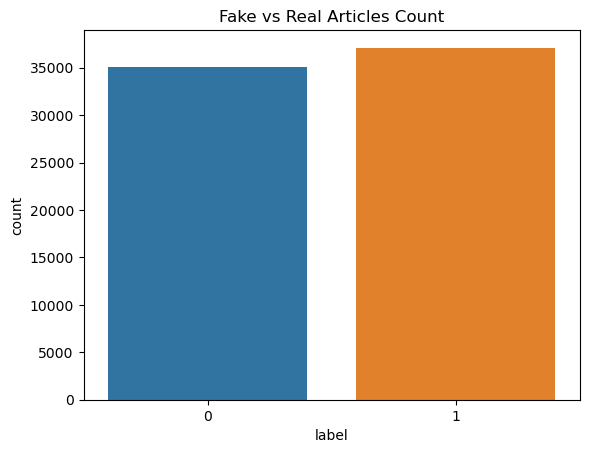

In [3]:
# Plot count of fake vs real articles, add title, and save figure
sns.countplot(x="label", data=df)
plt.title("Fake vs Real Articles Count")
plt.savefig("../OUTPUT/fake_vs_real_count.png", dpi=300, bbox_inches="tight")

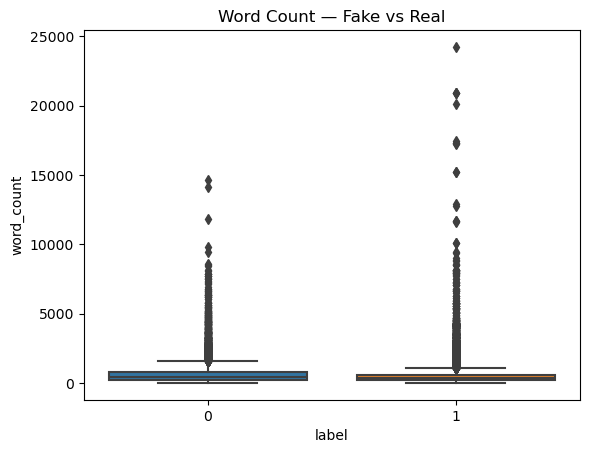

In [4]:
# Calculate word and character counts
df["word_count"] = df["text"].apply(lambda t: len(str(t).split()))
df["char_count"] = df["text"].apply(lambda t: len(str(t)))

# plot comparing word count for fake vs real articles, add title, and save figure
sns.boxplot(x="label", y="word_count", data=df)
plt.title("Word Count — Fake vs Real")
plt.savefig("../OUTPUT/fake_vs_real_word_count.png", dpi=300, bbox_inches="tight")

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

#top word counts from fake and real news articles
df_clean = df.dropna(subset=["text"])

# Separate fake and real article text
fake_text = df_clean[df_clean["label"] == 1]["text"]
real_text = df_clean[df_clean["label"] == 0]["text"]

# Create vectorizer to get top 20 words
cv = CountVectorizer(stop_words="english", max_features=20)

# Get word counts for fake articles
fake_counts = cv.fit_transform(fake_text)
fake_words = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "count": fake_counts.toarray().sum(axis=0)
}).sort_values(by="count", ascending=False)

# Get word counts for real articles
real_counts = cv.fit_transform(real_text)
real_words = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "count": real_counts.toarray().sum(axis=0)
}).sort_values(by="count", ascending=False)

# Display top words in fake and real articles
fake_words, real_words


(          word   count
 17       trump  106364
 14        said   49712
 12      people   48653
 1      clinton   45411
 13   president   38982
 6         just   34612
 7         like   31766
 5      hillary   31592
 11       obama   28615
 9          new   28334
 16        time   26155
 15       state   25340
 2       donald   24955
 10        news   21866
 0     american   20847
 8        media   20393
 3     election   20309
 4   government   20190
 19       world   19811
 18       white   19445,
           word   count
 12        said  184607
 17       trump  107201
 5           mr   66086
 9    president   51300
 6          new   42528
 8       people   41792
 13       state   38871
 14      states   31668
 2   government   30110
 11     reuters   29342
 3        house   28578
 1      clinton   28569
 19        year   28154
 18      united   27740
 10  republican   26548
 4         like   24796
 16        told   23991
 0     campaign   23383
 15        time   23335
 7        obama

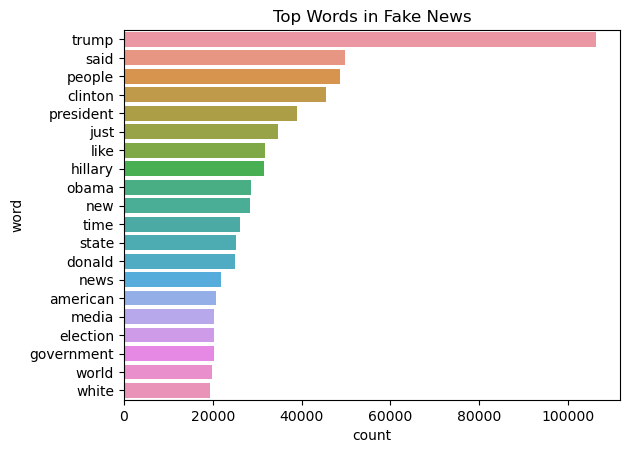

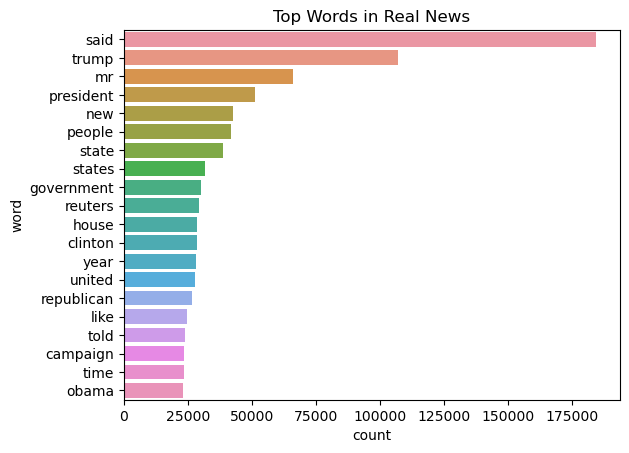

In [6]:
#plots of word counts for fake and real words, each plot is saved
sns.barplot(
    data=fake_words,
    x="count",
    y="word"
)
plt.title("Top Words in Fake News")
plt.savefig("../OUTPUT/fake_news_top_words.png", dpi=300, bbox_inches="tight")
plt.show()


sns.barplot(
    data=real_words,
    x="count",
    y="word"
)
plt.title("Top Words in Real News")
plt.savefig("../OUTPUT/real_news_top_words.png", dpi=300, bbox_inches="tight")
plt.show()


In [7]:
sample_size = 10000  # total sample size

# Create balanced sample with equal fake and real articles
df_sample = (
    df_clean
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(sample_size // 2, random_state=42))
)


C:\Users\yuanb\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


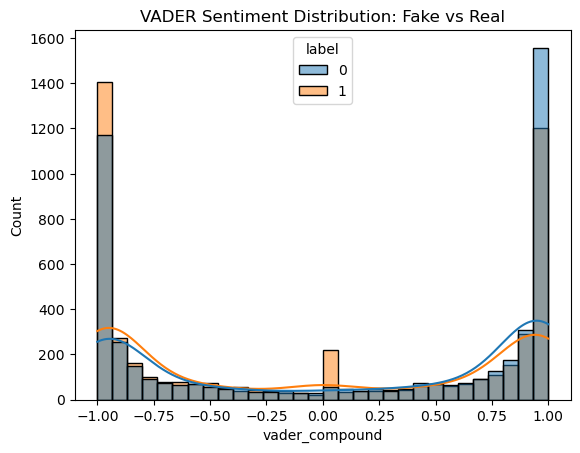

In [8]:
#sentiment analysis
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

# Calculate sentiment score (compound score) for each article
df_sample["vader_compound"] = df_sample["text"].apply(lambda t: analyzer.polarity_scores(t)["compound"])

# Plot sentiment score distribution for fake vs real news
sns.histplot(
    data=df_sample,
    x="vader_compound",
    hue="label",
    bins=30,
    kde=True
)

# Add title and save figure
plt.title("VADER Sentiment Distribution: Fake vs Real")
plt.savefig("../OUTPUT/vader_sentiment_dist_fake_vs_real.png", dpi=300, bbox_inches="tight")


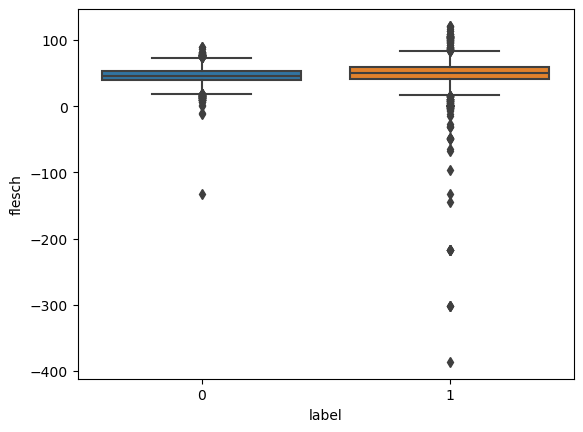

In [9]:
# Calculate readability score using Flesch Reading Ease
df_sample["flesch"] = df_sample["text"].apply(lambda t: textstat.flesch_reading_ease(str(t)))

# Create boxplot comparing readability of fake vs real news and save figure
sns.boxplot(x="label", y="flesch", data=df_sample)
plt.savefig("../OUTPUT/readability_real_vs_fake.png", dpi=300, bbox_inches="tight")

C:\Users\yuanb\AppData\Local\Temp\ipykernel_39156\3169945918.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["word_count"] = df_clean["text"].apply(lambda t: len(str(t).split()))


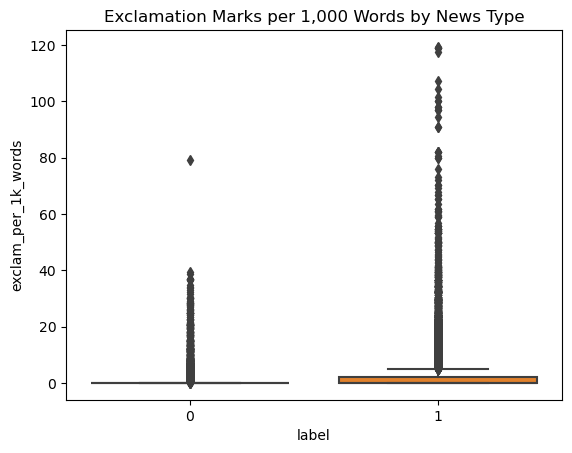

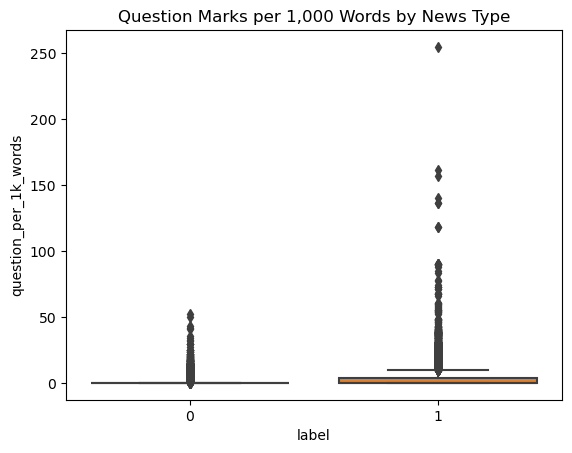

In [10]:
# Keep articles with at least 50 words and count teh number of ! and ?
df_clean["word_count"] = df_clean["text"].apply(lambda t: len(str(t).split()))
df_clean = df_clean[df_clean["word_count"] >= 50]
df_clean["exclamations"] = df_clean["text"].apply(lambda t: str(t).count("!"))
df_clean["questions"] = df_clean["text"].apply(lambda t: str(t).count("?"))

# Normalize exclamation marks per 1,000 words
df_clean["exclam_per_1k_words"] = (
    df_clean["exclamations"] / df_clean["word_count"]
) * 1000

# Normalize question marks per 1,000 words
df_clean["question_per_1k_words"] = (
    df_clean["questions"] / df_clean["word_count"]
) * 1000

# Plot exclamation marks comparison between fake and real news and save the figure
sns.boxplot(
    x="label",
    y="exclam_per_1k_words",
    data=df_clean
)
plt.title("Exclamation Marks per 1,000 Words by News Type")
plt.savefig("../OUTPUT/exclamationmarks_by_news_type.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot question marks comparison between fake and real news and save the figure
sns.boxplot(
    x="label",
    y="question_per_1k_words",
    data=df_clean
)
plt.title("Question Marks per 1,000 Words by News Type")
plt.savefig("../OUTPUT/questionmarks_by_news_type.png", dpi=300, bbox_inches="tight")
plt.show()


In [11]:
# Question marks per 1k words for fake news
fake_df = df_clean[df_clean["label"] == 1]

fake_df.sort_values(
    "question_per_1k_words",
    ascending=False
).head(10)[["text", "word_count", "question_per_1k_words", "label"]]


,text,word_count,question_per_1k_words,label
37815,White House deputy press secretary Sarah Hucka...,369,254.742547,1
64830,VOTE for Trump!!!! WE CAN DO IT GET OUT AND vo...,68,161.764706,1
69874,#TrumpTrain??????????@realDonaldTrump isn t go...,70,157.142857,1
18904,Shock!!!! Hasn't this been in the news for yea...,57,140.350877,1
31502,Can't say under God at Hilary speech!?!??!?? L...,110,136.363636,1
13860,Can't say under God at Hilary speech!?!??!?? L...,110,136.363636,1
14095,"Once you ve read this list, you re going to wa...",288,118.055556,1
61925,"Once you ve read this list, you re going to wa...",288,118.055556,1
912,iTS DARK ALRIGHT . In a sad twist of fate thes...,89,89.887640,1
2730,Wow! Just wow Where are you from?Syria.Syria?W...,89,89.887640,1


In [12]:
# Question marks per 1k words for real news
real_df = df_clean[(df_clean["label"] == 0)]

real_df.sort_values(
    "question_per_1k_words",
    ascending=False
).head(10)[["text", "word_count", "question_per_1k_words", "label"]]

,text,word_count,question_per_1k_words,label
20441,WASHINGTON (Reuters) - President Donald Trump ...,96,52.083333,0
55977,"During this week’s “Saturday Night Live,” Alec...",140,50.000000,0
29007,What if the latest craze among the big-governm...,920,43.478261,0
57615,"Friday in Washington, D. C. at the Partnership...",216,41.666667,0
37878,What if Hillary Clinton is in legal hot water ...,929,40.904198,0
17497,"NEW YORK, N.Y. — If Hillary Clinton is winning...",56,35.714286,0
8847,Opinions about the Supreme Court’s legitimacy ...,88,34.090909,0
65603,Asking @PressSec questions in Apple Store sinc...,154,32.467532,0
14267,Americans love their pets. of all households...,411,31.630170,0
51213,Pro-lifers have taken to social media to use P...,504,29.761905,0
